In [1]:
!pip install pandas numpy seaborn matplotlib plotly openpyxl flask


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import openpyxl
import flask
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "notebook"

Load Data

In [3]:
df = pd.read_excel("student_survey_messy.xlsx", engine='openpyxl')
#shape of data 
print(df.shape)

(10000, 13)


Explore Data

In [4]:
#first 5 data
print(df.head())

  student_id academic_year major facility_rated  satisfaction_score  gender  \
0    S100000           4th   CSE         Hostel                 4.0     NaN   
1    S100001           NaN    IT         Hostel                 NaN    Male   
2    S100002           3rd  MECH        Library                 4.0   Other   
3    S100003           NaN    IT         Sports                 3.0   male    
4    S100004           NaN   ECE            NaN                 5.0  Female   

   attendance_percentage  study_hours_per_week internet_quality  \
0                   93.0                  28.0              NaN   
1                   70.0                  48.0             Poor   
2                   88.0                  46.0          Average   
3                   74.0                   6.0            good    
4                   80.0                  18.0            good    

  hostel_resident  faculty_rating  placement_confidence feedback_text  
0            yes              2.0                 

In [5]:
df.dtypes


student_id                object
academic_year             object
major                     object
facility_rated            object
satisfaction_score       float64
gender                    object
attendance_percentage    float64
study_hours_per_week     float64
internet_quality          object
hostel_resident           object
faculty_rating           float64
placement_confidence     float64
feedback_text             object
dtype: object

In [6]:
#column names
df.columns

Index(['student_id', 'academic_year', 'major', 'facility_rated',
       'satisfaction_score', 'gender', 'attendance_percentage',
       'study_hours_per_week', 'internet_quality', 'hostel_resident',
       'faculty_rating', 'placement_confidence', 'feedback_text'],
      dtype='object')

In [7]:

# Data types
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             10000 non-null  object 
 1   academic_year          8311 non-null   object 
 2   major                  8600 non-null   object 
 3   facility_rated         8324 non-null   object 
 4   satisfaction_score     8806 non-null   float64
 5   gender                 7966 non-null   object 
 6   attendance_percentage  9846 non-null   float64
 7   study_hours_per_week   9786 non-null   float64
 8   internet_quality       7962 non-null   object 
 9   hostel_resident        7577 non-null   object 
 10  faculty_rating         8536 non-null   float64
 11  placement_confidence   8659 non-null   float64
 12  feedback_text          7983 non-null   object 
dtypes: float64(5), object(8)
memory usage: 1015.8+ KB


In [8]:

# Missing values
df.isnull().sum()


student_id                  0
academic_year            1689
major                    1400
facility_rated           1676
satisfaction_score       1194
gender                   2034
attendance_percentage     154
study_hours_per_week      214
internet_quality         2038
hostel_resident          2423
faculty_rating           1464
placement_confidence     1341
feedback_text            2017
dtype: int64

In [9]:

# Unique values per column
for col in df.columns:
    print(col, ":", df[col].nunique())

student_id : 10000
academic_year : 5
major : 6
facility_rated : 5
satisfaction_score : 5
gender : 4
attendance_percentage : 61
study_hours_per_week : 45
internet_quality : 4
hostel_resident : 3
faculty_rating : 5
placement_confidence : 5
feedback_text : 4


Data Cleaning and Tranformation

In [10]:
df['academic_year'] = df['academic_year'].str.strip()

In [11]:
df['academic_year'].unique()

array(['4th', nan, '3rd', '2nd', '1st'], dtype=object)

In [12]:
df['academic_year'].value_counts()

academic_year
2nd    3349
4th    1672
1st    1665
3rd    1625
Name: count, dtype: int64

In [13]:
df['academic_year'].value_counts(dropna=False)

academic_year
2nd    3349
NaN    1689
4th    1672
1st    1665
3rd    1625
Name: count, dtype: int64

In [14]:
df['academic_year'] = df['academic_year'].fillna('Unknown')

In [15]:
df['academic_year'].value_counts()

academic_year
2nd        3349
Unknown    1689
4th        1672
1st        1665
3rd        1625
Name: count, dtype: int64

In [16]:
df['major'].unique()

array(['CSE', 'IT', 'MECH', 'ECE', 'cse ', nan, 'CIVIL'], dtype=object)

In [17]:
df['major'].value_counts(dropna=False)

major
cse      1470
CIVIL    1458
CSE      1446
IT       1444
MECH     1427
NaN      1400
ECE      1355
Name: count, dtype: int64

In [18]:
df['major'] = df['major'].str.strip().str.upper()

In [19]:
df['major'] = df['major'].fillna('Unknown')

In [20]:
df['major'] = df['major'].replace({
    'CSE': 'Computer Science',
    'IT': 'Information Tech',
    'MECH': 'Mechanical',
    'ECE': 'Electronics',
    'CIVIL': 'Civil'
})

In [21]:
df['major'].value_counts(dropna=False)

major
Computer Science    2916
Civil               1458
Information Tech    1444
Mechanical          1427
Unknown             1400
Electronics         1355
Name: count, dtype: int64

In [22]:
df['facility_rated'].value_counts(dropna=False)

facility_rated
Hostel       1699
Sports       1676
NaN          1676
Library      1669
Labs         1644
Cafeteria    1636
Name: count, dtype: int64

In [23]:
df['facility_rated'] = df['facility_rated'].fillna('Not Rated')

In [24]:
df['satisfaction_score'].value_counts(dropna=False)


satisfaction_score
5.0    2642
3.0    2476
4.0    1284
1.0    1220
NaN    1194
2.0    1184
Name: count, dtype: int64

In [25]:
df['satisfaction_score'] = df['satisfaction_score'].fillna(df['satisfaction_score'].median())

In [26]:
df['satisfaction_score'] = df['satisfaction_score'].astype(int)

In [27]:
df['satisfaction_score'].value_counts(dropna=False)

satisfaction_score
3    3670
5    2642
4    1284
1    1220
2    1184
Name: count, dtype: int64

In [28]:
df['gender'].value_counts(dropna=False)

gender
NaN       2034
Female    2004
Other     2001
male      1988
Male      1973
Name: count, dtype: int64

In [29]:
df['gender'] = df['gender'].str.strip().str.capitalize()

In [30]:
df['gender'] = df['gender'].fillna('Unknown')

In [31]:
df['attendance_percentage'].value_counts(dropna=False)

attendance_percentage
60.0     313
85.0     291
97.0     199
75.0     182
81.0     175
        ... 
64.0     135
58.0     134
87.0     133
53.0     131
100.0    130
Name: count, Length: 62, dtype: int64

In [32]:
df['attendance_percentage'].unique()

array([ 93.,  70.,  88.,  74.,  80.,  67.,  65.,  45.,  73.,  83.,  85.,
        86.,  48.,  68.,  51.,  55.,  46.,  72.,  92.,  42.,  59.,  44.,
        77.,  54.,  95.,  62.,  41.,  75.,  60.,  53.,  98.,  nan,  81.,
        50.,  43.,  91.,  69.,  96.,  84.,  47.,  79.,  58.,  49.,  66.,
        52.,  56.,  63.,  90.,  97.,  76.,  64.,  61.,  82.,  89.,  87.,
        94.,  78.,  40.,  99., 100.,  71.,  57.])

In [33]:
df['attendance_percentage'].isnull().sum()


np.int64(154)

In [34]:
df['attendance_percentage'] = df['attendance_percentage'].fillna(
    df['attendance_percentage'].median()
)

In [35]:
df['attendance_percentage'] = df['attendance_percentage'].astype(float)

In [36]:
df['study_hours_per_week'].value_counts(dropna=False)

study_hours_per_week
27.0    250
6.0     246
36.0    241
44.0    238
9.0     238
26.0    236
49.0    235
25.0    233
23.0    231
20.0    229
42.0    228
13.0    224
43.0    223
32.0    222
15.0    220
46.0    219
39.0    219
7.0     219
28.0    219
8.0     217
48.0    217
33.0    216
29.0    216
17.0    215
14.0    215
34.0    214
21.0    214
NaN     214
47.0    213
37.0    212
22.0    211
5.0     211
18.0    211
19.0    210
24.0    209
11.0    208
40.0    207
10.0    206
30.0    206
41.0    204
31.0    202
38.0    198
16.0    198
45.0    196
35.0    196
12.0    194
Name: count, dtype: int64

In [37]:
df['study_hours_per_week'] = df.groupby('academic_year')['study_hours_per_week']\
    .transform(lambda x: x.fillna(x.median()))

In [38]:
df['internet_quality'].value_counts(dropna=False)

internet_quality
NaN        2038
Good       2008
Poor       2000
good       2000
Average    1954
Name: count, dtype: int64

In [39]:
df['internet_quality'] = df['internet_quality'].str.strip().str.capitalize()

In [40]:
df['internet_quality'] = df['internet_quality'].fillna('Unknown')

In [41]:
df['hostel_resident'].value_counts(dropna=False)

hostel_resident
yes     2569
No      2517
Yes     2491
NaN     2423
Name: count, dtype: int64

In [42]:
df['hostel_resident'] = df['hostel_resident'].str.strip().str.capitalize()

In [43]:
df['hostel_resident'] = df['hostel_resident'].fillna('Unknown')

In [44]:
df['faculty_rating'].value_counts(dropna=False)

faculty_rating
4.0    2826
2.0    1469
NaN    1464
5.0    1432
3.0    1405
1.0    1404
Name: count, dtype: int64

In [45]:
df['faculty_rating'] = df.groupby('academic_year')['faculty_rating']\
    .transform(lambda x: x.fillna(x.median()))

In [46]:
df['faculty_rating'] = df['faculty_rating'].astype(int)

In [47]:
df['placement_confidence'].value_counts(dropna=False)

placement_confidence
3.0    2849
5.0    1489
2.0    1458
1.0    1451
4.0    1412
NaN    1341
Name: count, dtype: int64

In [48]:
df['placement_confidence'] = df.groupby('academic_year')['placement_confidence']\
    .transform(lambda x: x.fillna(x.median()))

In [49]:
df['placement_confidence'] = df['placement_confidence'].astype(int)

In [50]:
df['feedback_text'].value_counts(dropna=False)

feedback_text
Good                 2081
NaN                  2017
Average              1987
Bad                  1986
Needs improvement    1929
Name: count, dtype: int64

In [51]:
df['feedback_text'] = df['feedback_text'].fillna('Unknown')

In [52]:
df.dtypes

student_id                object
academic_year             object
major                     object
facility_rated            object
satisfaction_score         int64
gender                    object
attendance_percentage    float64
study_hours_per_week     float64
internet_quality          object
hostel_resident           object
faculty_rating             int64
placement_confidence       int64
feedback_text             object
dtype: object

In [53]:
df.isnull().sum()

student_id               0
academic_year            0
major                    0
facility_rated           0
satisfaction_score       0
gender                   0
attendance_percentage    0
study_hours_per_week     0
internet_quality         0
hostel_resident          0
faculty_rating           0
placement_confidence     0
feedback_text            0
dtype: int64

In [54]:
# Convert academic year to ordered category
year_order = ["1st", "2nd", "3rd", "4th"]
df['academic_year'] = pd.Categorical(df['academic_year'], categories=year_order, ordered=True)

# Create satisfaction category
df['satisfaction_level'] = pd.cut(
    df['satisfaction_score'],
    bins=[0,2,3,5],
    labels=["Low", "Medium", "High"]
)



In [55]:
df['satisfaction_level'].value_counts(dropna=False)

satisfaction_level
High      3926
Medium    3670
Low       2404
Name: count, dtype: int64

In [66]:
df.to_excel("cleaned_data.xlsx", index=False)

In [57]:
total_students = df['student_id'].nunique()
avg_satisfaction = df['satisfaction_score'].mean()
avg_faculty_rating = df['faculty_rating'].mean()
avg_placement = df['placement_confidence'].mean()

print("Total Students:", total_students)
print("Avg Satisfaction:", round(avg_satisfaction,2))
print("Avg Faculty Rating:", round(avg_faculty_rating,2))
print("Avg Placement Confidence:", round(avg_placement,2))

Total Students: 10000
Avg Satisfaction: 3.29
Avg Faculty Rating: 3.22
Avg Placement Confidence: 3.0


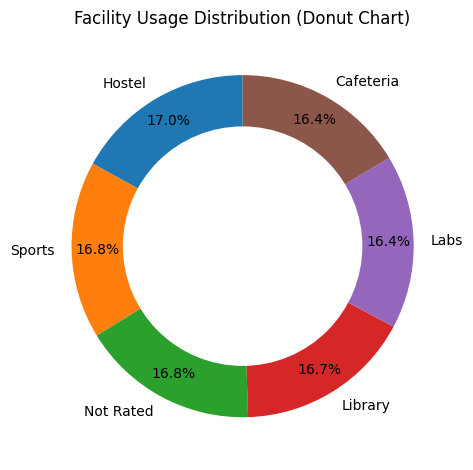

In [58]:
import matplotlib.pyplot as plt

facility_counts = df['facility_rated'].value_counts()

plt.figure()

plt.pie(
    facility_counts,
    labels=facility_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.85
)

# Donut hole
centre_circle = plt.Circle((0,0), 0.70, fc='white')
plt.gca().add_artist(centre_circle)

plt.title("Facility Usage Distribution (Donut Chart)")
plt.tight_layout()
plt.show()

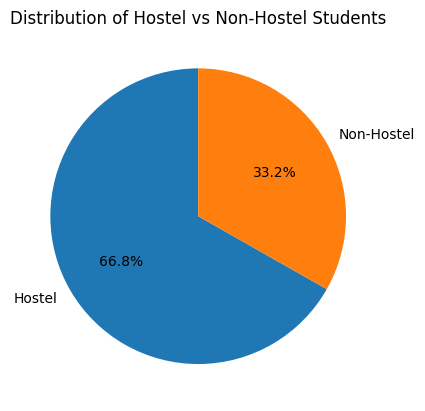

In [59]:
import matplotlib.pyplot as plt

# Clean values
df['hostel_resident'] = df['hostel_resident'].str.lower().str.strip()

# Keep only valid data
df_hostel = df[df['hostel_resident'].isin(['yes', 'no'])]

# Count
hostel_counts = df_hostel['hostel_resident'].value_counts()

# Plot pie chart
plt.figure()

plt.pie(
    hostel_counts,
    labels=['Hostel', 'Non-Hostel'],
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Distribution of Hostel vs Non-Hostel Students")
plt.ylabel("")
plt.show()

C:\Users\dell\AppData\Local\Temp\ipykernel_12008\3440835413.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  yearly = df.groupby('academic_year')['satisfaction_score'].mean()


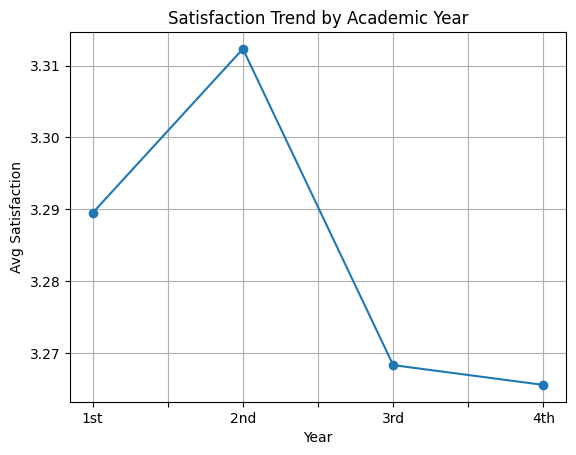

In [60]:
yearly = df.groupby('academic_year')['satisfaction_score'].mean()

plt.figure()
yearly.plot(marker='o')
plt.title("Satisfaction Trend by Academic Year")
plt.xlabel("Year")
plt.ylabel("Avg Satisfaction")
plt.grid()
plt.show()

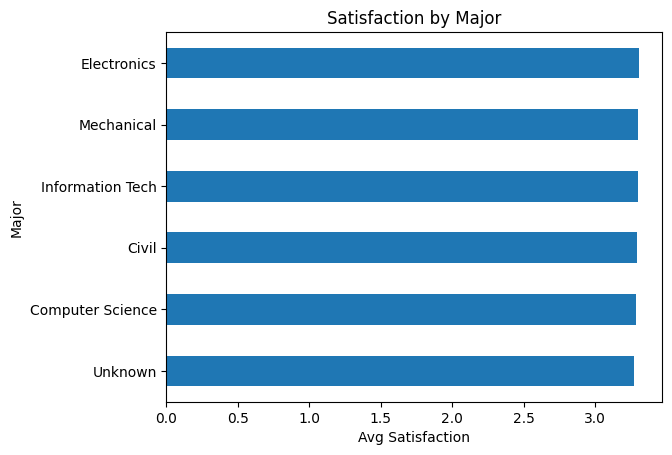

In [61]:
major_avg = df.groupby('major')['satisfaction_score'].mean().sort_values()

plt.figure()
major_avg.plot(kind='barh')
plt.title("Satisfaction by Major")
plt.xlabel("Avg Satisfaction")
plt.ylabel("Major")
plt.show()

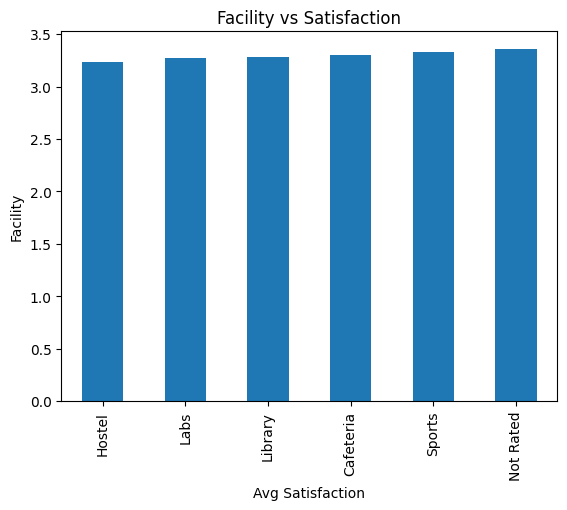

In [62]:
facility_avg = df.groupby('facility_rated')['satisfaction_score'].mean().sort_values()

plt.figure()
facility_avg.plot(kind='bar')
plt.title("Facility vs Satisfaction")
plt.xlabel("Avg Satisfaction")
plt.ylabel("Facility")
plt.show()

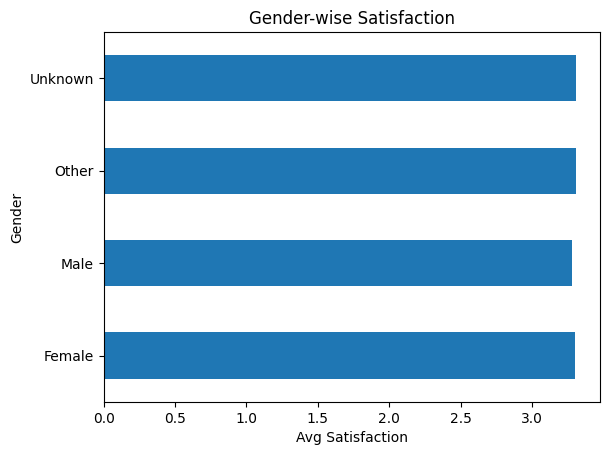

In [63]:
gender_avg = df.groupby('gender')['satisfaction_score'].mean()

plt.figure()
gender_avg.plot(kind='barh')  # 🔥 changed here

plt.title("Gender-wise Satisfaction")
plt.xlabel("Avg Satisfaction")
plt.ylabel("Gender")

plt.show()

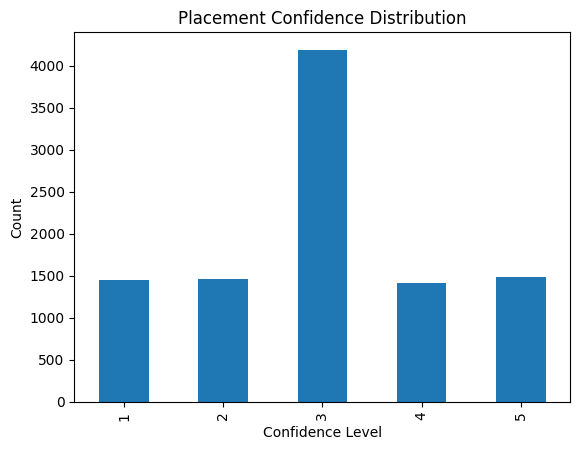

In [64]:
placement_counts = df['placement_confidence'].value_counts().sort_index()

plt.figure()
placement_counts.plot(kind='bar')
plt.title("Placement Confidence Distribution")
plt.xlabel("Confidence Level")
plt.ylabel("Count")
plt.show()

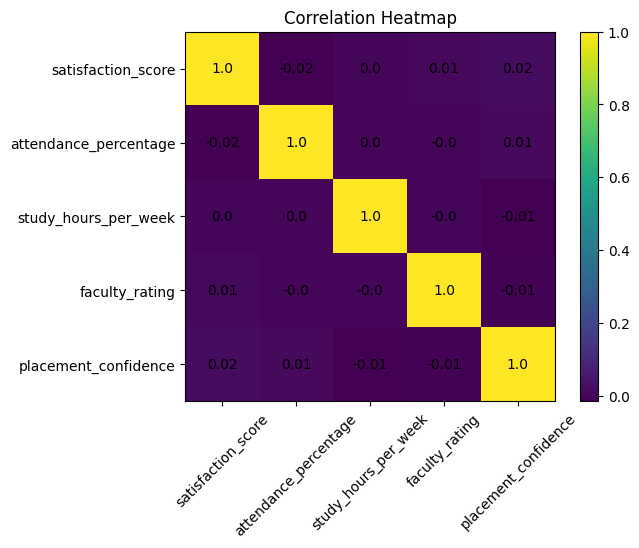

In [65]:
numeric_cols = [
    'satisfaction_score',
    'attendance_percentage',
    'study_hours_per_week',
    'faculty_rating',
    'placement_confidence'
]

corr = df[numeric_cols].corr()

import matplotlib.pyplot as plt
import numpy as np

plt.figure()
plt.imshow(corr)
plt.colorbar()

# Axis labels
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

# 🔥 ADD VALUES INSIDE CELLS
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, round(corr.iloc[i, j], 2),
                 ha='center', va='center')

plt.title("Correlation Heatmap")
plt.show()